In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Dense,Flatten
from tensorflow.keras.activations import relu,softmax

df = pd.read_csv('train.csv')
target0 = df[df.target == 0]
target1 = df[df.target == 1]
xs = np.vstack((target0,target1))
labels = target1.target
target1 = target1.drop('target',axis = 1)
target1 = target1.drop('id',axis = 1)
target1 = np.reshape(target1,(200,32,32,3))
target0 = target0.drop('id',axis = 1)
target0 = target0.drop('target',axis = 1)
target0 = np.reshape(target0,(1800,32,32,3))

original_labels = xs[:,3073]
xs = xs[:,1:3073]



datagen = ImageDataGenerator(
    shear_range = 0.1,
    zoom_range = 0.1,
    rotation_range = 20,
    horizontal_flip = True,
    vertical_flip = False,
    width_shift_range = 0.2,
    height_shift_range = 0.2
)

generator1 = datagen.flow(
    target1,
    batch_size = 200
)

original_labels = np.reshape(original_labels,(2000,1))
images = next(generator1)
label = np.ones((200,1))
images = np.reshape(images,(200,3072))
original_labels = np.vstack((original_labels,label))
xs = np.vstack((xs,np.reshape(images,(200,3072))))
for _ in range(8):
  images = next(generator1)
  label = np.ones((200,1))
  images = np.reshape(images,(200,3072))
  original_labels = np.vstack((original_labels,label))
  xs = np.vstack((xs,images))

generator0 = datagen.flow(
    target0,
    batch_size = 200
)

images = next(generator0)
label = np.zeros((200,1))
images = np.reshape(images,(200,3072))
original_labels = np.vstack((original_labels,label))
xs = np.vstack((xs,np.reshape(images,(200,3072))))
# for _ in range(0):
#   images = next(generator0)
#   label = np.zeros((200,1))
#   images = np.reshape(images,(200,3072))
#   original_labels = np.vstack((original_labels,label))
#   xs = np.vstack((xs,np.reshape(images,(200,3072))))

random_indices = np.random.permutation(len(original_labels))

xs = xs[random_indices]
original_labels = original_labels[random_indices]



In [74]:
target0.shape

(1800, 32, 32, 3)

In [2]:
xs.shape


(4000, 3072)

In [51]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import BatchNormalization,Dropout
from tensorflow.keras.regularizers import l1,l2
model = Sequential([
    Conv2D(32,(3,3)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(64,(3,3),activation = 'relu',kernel_regularizer=l1(0.001)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(128,(3,3),activation='relu',kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    tf.keras.layers.GlobalAveragePooling2D(),

    BatchNormalization(),
    Dropout(0.25),
    BatchNormalization(),
    Dense(units = 64,activation = relu),
    BatchNormalization(),
    Dense(units = 2,activation = softmax)
])
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(xs,original_labels,stratify = original_labels,test_size = 0.1)
x_train = x_train/255
x_test = x_test/255
class myCallBack(tf.keras.callbacks.Callback):
  def on_epoch_end(self,epoch,logs ={}):
    if(logs.get('accuracy') > 0.95):
      print("Model has accquired an accuracy of 85% on training dataset")
      self.model.stop_training = True
dynamiclr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor = 0.5,
    patience = 5,
    verbose = 1,
    mode ='auto',
    min_delta = 0.001,
    cooldown = 0,
    min_lr = 1e-6
  )
stopearly = tf.keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    start_from_epoch=6,
    patience = 10,
    verbose = 1,
    min_delta = 0.0001,
    restore_best_weights=True
  )
model.compile(
    optimizer =tf.keras.optimizers.Adam(learning_rate = 0.001),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy'])
history = model.fit(np.reshape(x_train,(3600,32,32,3)),y_train,callbacks = [myCallBack(),dynamiclr,stopearly],epochs = 100,validation_data=(np.reshape(x_test,(400,32,32,3)),y_test))

Epoch 1/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 13s 70ms/step - accuracy: 0.7128 - loss: 1.4462 - val_accuracy: 0.5000 - val_loss: 1.6900 - learning_rate: 0.0010
Epoch 2/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 8s 71ms/step - accuracy: 0.8310 - loss: 1.1869 - val_accuracy: 0.5000 - val_loss: 1.5634 - learning_rate: 0.0010
Epoch 3/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.8459 - loss: 1.0496 - val_accuracy: 0.5000 - val_loss: 1.7970 - learning_rate: 0.0010
Epoch 4/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 8s 72ms/step - accuracy: 0.8661 - loss: 0.9103 - val_accuracy: 0.5450 - val_loss: 1.3817 - learning_rate: 0.0010
Epoch 5/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - accuracy: 0.8569 - loss: 0.8400 - val_accuracy: 0.8900 - val_loss: 0.7304 - learning_rate: 0.0010
Epoch 6/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 8s 73ms/step - accuracy: 0.8623 - loss: 0.7428 - val_accuracy: 0.8500 - val_loss: 0.7107 - learning_rate: 0.0010
Epoch 7/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.8839 - 

In [52]:
model.evaluate(np.reshape(x_test,(400,32,32,3)),y_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9158 - loss: 0.4317


[0.43905967473983765, 0.9125000238418579]

In [56]:
def create_aug_data(target0,target1):
  aug_datagen = ImageDataGenerator(
    shear_range = 0.15,
    zoom_range = 0.15,
    horizontal_flip = True,
  )

  aug_generator = aug_datagen.flow(
    target0,
    batch_size = 400
  )
  test_images = next(aug_generator)
  test_labels = np.zeros((400,1))

  aug_generator = aug_datagen.flow(
    target1,
    batch_size = 200
  )

  test_images = np.vstack((test_images,next(aug_generator)))
  test_labels = np.vstack((test_labels,np.ones((200,1))))
  test_images = np.vstack((test_images,next(aug_generator)))
  test_labels = np.vstack((test_labels,np.ones((200,1))))
  return [test_images,test_labels]



In [57]:
accuracy = [model.evaluate(create_aug_data(target0,target1)[0]/255,create_aug_data(target0,target1)[1])[1] for _ in range(5)]
x = np.mean(accuracy)
y = np.float64(0.6870000004768372)
(y-x)/y

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7758 - loss: 0.6652
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7836 - loss: 0.6573
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7270 - loss: 0.7684
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7697 - loss: 0.6888
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7694 - loss: 0.6623


np.float64(-0.16921397715210815)

In [58]:
x

np.float64(0.803250002861023)

In [59]:
y = pd.read_csv('test.csv')
idx = y.id
y = y.drop('id',axis = 1)
y = y/255
def label_generator(x):
  z = []
  for l in x:
    if l[0] > l[1]:
      z.append(0)
    else:
      z.append(1)
  return z
proba = model.predict(np.reshape(y,(2000,32,32,3)))


63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step


In [60]:
pred_target = label_generator(proba)

In [61]:
dataframe = pd.DataFrame({'id' : idx,'target' : pred_target})
dataframe.set_index('id')
dataframe.to_csv('submission.csv',index = False)

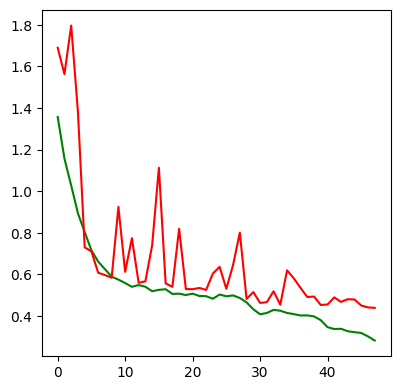

In [62]:
plt.figure(figsize=(4.5,4.5))
plt.plot(history.history['loss'],color = 'green')
plt.plot(history.history['val_loss'],color = 'red')
plt.show()